# 🌿 Notebook 01 — Reverse-Transform GBIF & sPlot Trait Maps

## Background

Both GBIF and sPlot trait maps were pre-processed using sklearn's `PowerTransformer(method='yeo-johnson', standardize=True)`.  
This applies **two sequential steps**:

```
raw trait value
      │
      ▼  Step 1: Yeo-Johnson power transform  (makes distribution normal)
transformed value
      │
      ▼  Step 2: Z-score standardisation  (mean=0, std=1)
final map value  ← this is what is stored in the TIF files
```

To recover original trait values we **reverse both steps in opposite order**:

```
map value (stored in TIF)
      │
      ▼  Step 1: Un-standardise   →   y = x * scale + mean
power-transformed value
      │
      ▼  Step 2: Inverse Yeo-Johnson  (using scipy)
original trait value  ← biological units (e.g. mm², mg/g, m²/kg)
```

The parameters for each trait are stored in `power_transform_params.csv`:

| Column | Role |
|--------|------|
| `trait` | Trait ID (e.g. X14, X1080) |
| `yeo_johnson_lambda` | λ used in the power transform |
| `standardize_mean` | Mean subtracted after power transform |
| `standardize_scale` | Std divided after power transform |

**Same parameters apply to both GBIF and sPlot** — the transform was fitted on the combined/reference distribution.

---

## 0. Imports & Setup


In [1]:
import os
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import rasterio
import rasterio.crs

from scipy.special import inv_boxcox1p

plt.rcParams.update(
    {"figure.dpi": 120, "axes.titlesize": 10, "font.family": "sans-serif"}
)
sns.set_style("whitegrid")

print("✅ All imports successful")

✅ All imports successful


In [ ]:
ROOT = "/scratch3/plant-traits-v2/data"

PATHS = {
    "gbif": os.path.join(ROOT, "22km", "gbif"),
    "splot": os.path.join(ROOT, "22km", "splot"),
    "transform_csv": os.path.join(ROOT, "power_transformer_params.csv"),
    "out_gbif": os.path.join(ROOT, "22km", "gbif_original"),  # output folder
    "out_splot": os.path.join(ROOT, "22km", "splot_original"),  # output folder
}

os.makedirs(PATHS["out_gbif"], exist_ok=True)
os.makedirs(PATHS["out_splot"], exist_ok=True)

for name, path in PATHS.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'}  {name:20s}  {path}")

✅  gbif                  /scratch3/plant-traits-v2/data/22km/gbif
✅  splot                 /scratch3/plant-traits-v2/data/22km/splot
✅  transform_csv         /scratch3/plant-traits-v2/data/power_transformer_params.csv
✅  out_gbif              /scratch3/plant-traits-v2/data/22km/gbif_original
✅  out_splot             /scratch3/plant-traits-v2/data/22km/splot_original


---
## 1. Load Transformation Parameters

In [4]:
params_df = pd.read_csv(PATHS["transform_csv"])

# Set trait as index for easy lookup
params = params_df.set_index("trait")

print(f"Parameters loaded: {len(params)} traits")
print(f"Traits: {params.index.tolist()}")
params

Parameters loaded: 32 traits
Traits: ['X3117', 'X14', 'X50', 'X146', 'X3120', 'X297', 'X21', 'X13', 'X15', 'X3113', 'X3112', 'X47', 'X169', 'X3106', 'X144', 'X27', 'X26', 'X55', 'X46', 'X281', 'X282', 'X289', 'X163', 'X145', 'X237', 'X614', 'X6', 'X95', 'X138', 'X1080', 'X78', 'X4']


,yeo_johnson_lambda,standardize_mean,standardize_scale
trait,,,
X3117,0.135641,3.292038,0.675721
X14,0.294290,4.951056,0.780634
X50,-0.696778,0.675542,0.119878
X146,-0.407898,1.791778,0.089878
X3120,-0.498594,1.032026,0.170561
X297,0.077208,2.608437,0.539573
X21,-10.148966,0.038466,0.028456
X13,1.410638,4036.621787,341.106533
X15,-0.387341,0.724772,0.195989


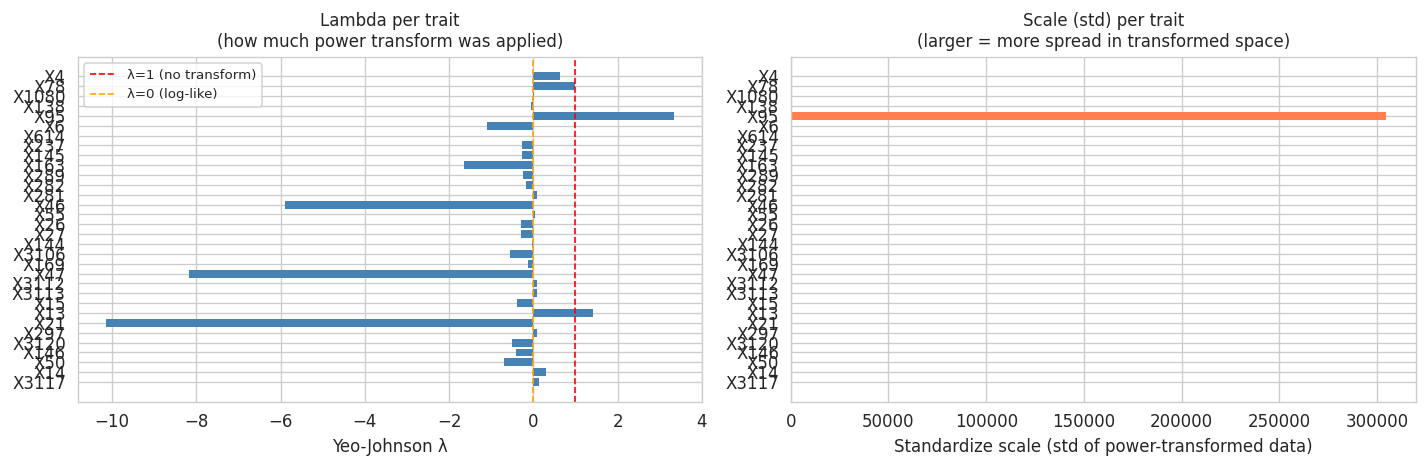

In [5]:
# ── Inspect the lambda values ────────────────────────────────────────────────
# lambda ≈ 1  → almost no power transform was needed (data was near-normal)
# lambda ≈ 0  → log-like transform was applied (data was right-skewed)
# lambda < 0  → strong transform (heavy skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(
    params.index, params["yeo_johnson_lambda"], color="steelblue", edgecolor="none"
)
axes[0].axvline(1, color="red", ls="--", lw=1, label="λ=1 (no transform)")
axes[0].axvline(0, color="orange", ls="--", lw=1, label="λ=0 (log-like)")
axes[0].set_xlabel("Yeo-Johnson λ")
axes[0].set_title("Lambda per trait\n(how much power transform was applied)")
axes[0].legend(fontsize=8)

axes[1].barh(params.index, params["standardize_scale"], color="coral", edgecolor="none")
axes[1].set_xlabel("Standardize scale (std of power-transformed data)")
axes[1].set_title("Scale (std) per trait\n(larger = more spread in transformed space)")

plt.tight_layout()
plt.show()

---
## 2. The Back-Transformation Function

### The inverse Yeo-Johnson transform

For a power-transformed value `y` with parameter `λ`, the inverse is:

| Condition | Formula |
|-----------|----------|
| `y ≥ 0` and `λ ≠ 0` | `(y·λ + 1)^(1/λ) - 1` |
| `y ≥ 0` and `λ = 0` | `exp(y) - 1` |
| `y < 0` and `λ ≠ 2` | `1 - (-(2-λ)·y + 1)^(1/(2-λ))` |
| `y < 0` and `λ = 2` | `1 - exp(-y)` |

We use scipy's `inv_boxcox1p` which implements this efficiently and handles edge cases.

In [ ]:
def inverse_yeo_johnson(y, lmbda):
    """
    Inverse Yeo-Johnson transform.

    Yeo-Johnson is Box-Cox applied to (y+1) for y>=0,
    and a modified Box-Cox applied to (-y+1) for y<0.
    scipy's inv_boxcox1p handles the positive branch;
    we mirror it for the negative branch.

    Parameters
    ----------
    y      : np.ndarray  — power-transformed values (after un-standardising)
    lmbda  : float       — Yeo-Johnson lambda

    Returns
    -------
    x_orig : np.ndarray  — original values
    """
    y = np.asarray(y, dtype=np.float64)
    x = np.empty_like(y)

    pos = y >= 0
    neg = ~pos

    # Positive branch: inverse Box-Cox1p with lambda
    if pos.any():
        x[pos] = inv_boxcox1p(y[pos], lmbda)

    # Negative branch: inverse Box-Cox1p with (2 - lambda), then negate
    if neg.any():
        x[neg] = -inv_boxcox1p(-y[neg], 2 - lmbda)

    return x


def back_transform(values, trait_id):
    """
    Full back-transformation pipeline:
      map value → un-standardise → inverse Yeo-Johnson → original trait value

    Parameters
    ----------
    values   : array-like  — raw values from TIF file
    trait_id : str         — trait name matching the params CSV index

    Returns
    -------
    np.ndarray of original trait values
    """
    p = params.loc[trait_id]
    lmbda = p["yeo_johnson_lambda"]
    mean_ = p["standardize_mean"]
    scale_ = p["standardize_scale"]

    # Step 1: Un-standardise  (reverse z-score)
    y = np.asarray(values, dtype=np.float64) * scale_ + mean_

    # Step 2: Inverse Yeo-Johnson
    x_orig = inverse_yeo_johnson(y, lmbda)

    return x_orig


# ── Quick sanity check with synthetic data ───────────────────────────────────

trait_test = params.index[0]
p_test = params.loc[trait_test]

test_standardised = np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 2.0])

# Un-standardise
test_power = (
    test_standardised * p_test["standardize_scale"] + p_test["standardize_mean"]
)

# Inverse Yeo-Johnson
test_original = inverse_yeo_johnson(test_power, p_test["yeo_johnson_lambda"])

df_check = pd.DataFrame(
    {
        "standardised (map value)": test_standardised,
        "after un-standardise": test_power,
        "after inverse YJ (original)": test_original,
    }
)
print(f"Trait used for check: {trait_test}  (λ={p_test['yeo_johnson_lambda']:.4f})")
df_check

Trait used for check: X3117  (λ=0.1356)


,standardised (map value),after un-standardise,after inverse YJ (original)
0,-2.0,1.940596,4.599577
1,-1.0,2.616317,8.384817
2,0.0,3.292038,14.205840
3,0.5,3.629899,18.136959
4,1.0,3.967759,22.917443
5,2.0,4.643480,35.646349


---
## 3. Helper: Extract Trait ID from Filename

We need to match each TIF filename to its row in `power_transform_params.csv`.

In [ ]:
def extract_trait_id(filepath):
    """
    Extract the trait ID from a TIF filename.
    Tries to match against the known trait IDs in params.
    e.g. 'X14_splot.tif' → 'X14'
         'gbif_X1080.tif' → 'X1080'
    """
    fname = os.path.basename(filepath).replace(".tif", "")
    if fname in params.index:
        return fname
    for trait in params.index:
        if trait in fname:
            return trait
    return None


# ── Test on all GBIF files ───────────────────────────────────────────────────
gbif_files = sorted(glob.glob(os.path.join(PATHS["gbif"], "*.tif")))
splot_files = sorted(glob.glob(os.path.join(PATHS["splot"], "*.tif")))

print("GBIF filename → trait ID mapping:")
gbif_map = {}
for f in gbif_files:
    tid = extract_trait_id(f)
    gbif_map[f] = tid
    status = "✅" if tid else "❌ NO MATCH"
    print(f"  {status}  {os.path.basename(f):40s} → {tid}")

print("\nsPlot filename → trait ID mapping:")
splot_map = {}
for f in splot_files:
    tid = extract_trait_id(f)
    splot_map[f] = tid
    status = "✅" if tid else "❌ NO MATCH"
    print(f"  {status}  {os.path.basename(f):40s} → {tid}")

GBIF filename → trait ID mapping:
  ✅  X1080.tif                                → X1080
  ✅  X13.tif                                  → X13
  ✅  X138.tif                                 → X138
  ✅  X14.tif                                  → X14
  ✅  X144.tif                                 → X144
  ✅  X145.tif                                 → X145
  ✅  X146.tif                                 → X146
  ✅  X15.tif                                  → X15
  ✅  X163.tif                                 → X163
  ✅  X169.tif                                 → X169
  ✅  X21.tif                                  → X21
  ❌ NO MATCH  X223.tif                                 → None
  ❌ NO MATCH  X224.tif                                 → None
  ✅  X237.tif                                 → X237
  ✅  X26.tif                                  → X26
  ✅  X27.tif                                  → X27
  ✅  X281.tif                                 → X281
  ✅  X282.tif                                 → X282

In [ ]:
unmatched_gbif = [f for f, t in gbif_map.items() if t is None]
unmatched_splot = [f for f, t in splot_map.items() if t is None]

if unmatched_gbif or unmatched_splot:
    print("⚠️  Files without a trait match (fix manually above):")
    for f in unmatched_gbif + unmatched_splot:
        print(f"   {os.path.basename(f)}")
else:
    print("✅ All files matched to a trait ID")

⚠️  Files without a trait match (fix manually above):
   X223.tif
   X224.tif
   X3107.tif
   X3114.tif
   X351.tif
   X223.tif
   X224.tif
   X3107.tif
   X3114.tif
   X351.tif


---
## 4. Back-Transform a Single Trait (Detailed Inspection)

Before running everything in bulk, we inspect one trait in detail to make sure the back-transform looks correct.

In [10]:
def back_transform_tif(filepath, trait_id, nodata_out=np.nan):
    """
    Read a TIF, apply back-transformation, return (original_array, rasterio_profile).
    Nodata pixels are preserved as nan.
    """
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float64)
        nodata = src.nodata
        profile = src.profile.copy()

    # Mask nodata
    if nodata is not None:
        mask = data == nodata
    else:
        mask = np.zeros_like(data, dtype=bool)

    # Back-transform valid pixels only
    flat = data.copy()
    flat[mask] = 0.0  # temporary safe value
    transformed = back_transform(flat, trait_id)
    transformed[mask] = np.nan  # restore nodata as nan

    # Update profile for output
    profile.update(dtype="float32", nodata=np.nan)

    return transformed.astype(np.float32), profile


def plot_before_after(filepath, trait_id, source_label="GBIF"):
    """
    4-panel plot: spatial maps and histograms before and after back-transformation.
    """
    # --- Load raw (normalised) data
    with rasterio.open(filepath) as src:
        raw = src.read(1).astype(np.float64)
        nodata = src.nodata
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    if nodata is not None:
        raw[raw == nodata] = np.nan
    valid_raw = raw[~np.isnan(raw)]

    # --- Back-transform
    orig, _ = back_transform_tif(filepath, trait_id)
    valid_orig = orig[~np.isnan(orig)]

    # --- Plot
    fig = plt.figure(figsize=(16, 7))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    p = params.loc[trait_id]
    fig.suptitle(
        f"{source_label} — {trait_id}  "
        f"(λ={p['yeo_johnson_lambda']:.3f}, "
        f"mean={p['standardize_mean']:.3f}, "
        f"scale={p['standardize_scale']:.3f})",
        fontsize=12,
        fontweight="bold",
    )

    # Top-left: normalised spatial map
    ax1 = fig.add_subplot(gs[0, 0])
    vmin, vmax = np.nanpercentile(valid_raw, [2, 98])
    im1 = ax1.imshow(
        raw, cmap="viridis", vmin=vmin, vmax=vmax, extent=extent, aspect="auto"
    )
    plt.colorbar(im1, ax=ax1, fraction=0.03)
    ax1.set_title("BEFORE — normalised map value")

    # Bottom-left: normalised histogram
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(valid_raw, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
    ax2.axvline(
        np.nanmean(valid_raw),
        color="red",
        ls="--",
        lw=1.5,
        label=f"mean={np.nanmean(valid_raw):.3f}",
    )
    ax2.set_title("BEFORE — distribution (should look ≈ normal)")
    ax2.set_xlabel("Normalised value")
    ax2.legend(fontsize=8)

    # Top-right: original spatial map
    ax3 = fig.add_subplot(gs[0, 1])
    vmin2, vmax2 = np.nanpercentile(valid_orig, [2, 98])
    im3 = ax3.imshow(
        orig, cmap="viridis", vmin=vmin2, vmax=vmax2, extent=extent, aspect="auto"
    )
    plt.colorbar(im3, ax=ax3, fraction=0.03)
    ax3.set_title("AFTER — original trait units")

    # Bottom-right: original histogram
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(valid_orig, bins=100, color="coral", edgecolor="none", alpha=0.8)
    ax4.axvline(
        np.nanmean(valid_orig),
        color="red",
        ls="--",
        lw=1.5,
        label=f"mean={np.nanmean(valid_orig):.3f}",
    )
    ax4.set_title("AFTER — distribution (should look biological / right-skewed)")
    ax4.set_xlabel("Original trait value")
    ax4.legend(fontsize=8)

    plt.show()

    # Stats comparison
    print(
        f"  BEFORE  → min={valid_raw.min():.4f}, max={valid_raw.max():.4f}, "
        f"mean={valid_raw.mean():.4f}, std={valid_raw.std():.4f}"
    )
    print(
        f"  AFTER   → min={valid_orig.min():.4f}, max={valid_orig.max():.4f}, "
        f"mean={valid_orig.mean():.4f}, std={valid_orig.std():.4f}"
    )


print("✅ Functions defined")

✅ Functions defined


File:  X237.tif
Trait: X237



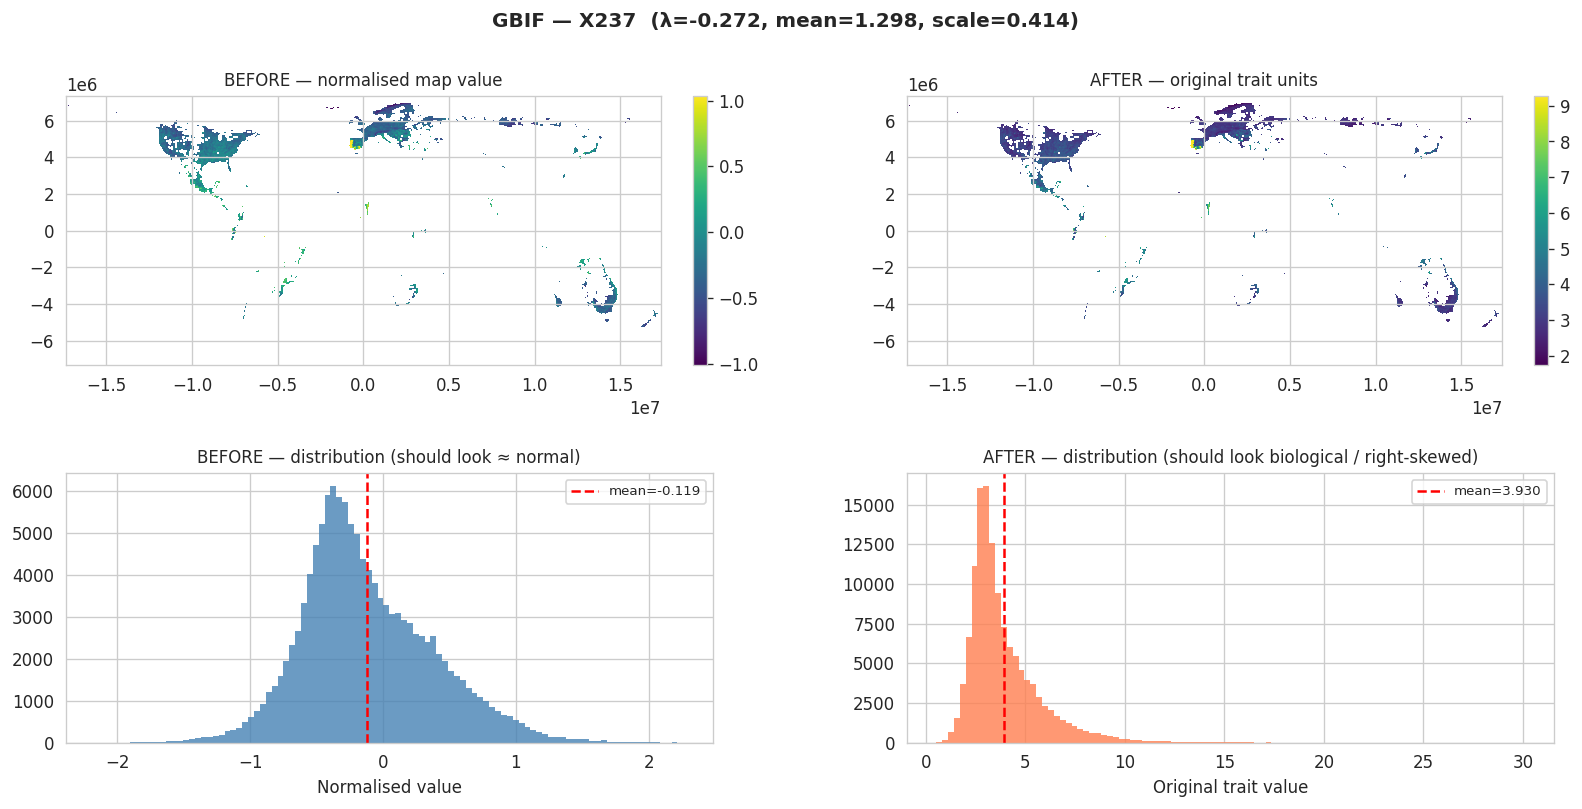

  BEFORE  → min=-2.1658, max=2.2607, mean=-0.1188, std=0.4958
  AFTER   → min=0.5288, max=30.0741, mean=3.9300, std=1.9038


In [14]:
# ── Inspect the first GBIF trait in detail ───────────────────────────────────
example_gbif_file = gbif_files[13]
example_trait = gbif_map[example_gbif_file]

print(f"File:  {os.path.basename(example_gbif_file)}")
print(f"Trait: {example_trait}")
print()

plot_before_after(example_gbif_file, example_trait, source_label="GBIF")

File:  X237.tif
Trait: X237



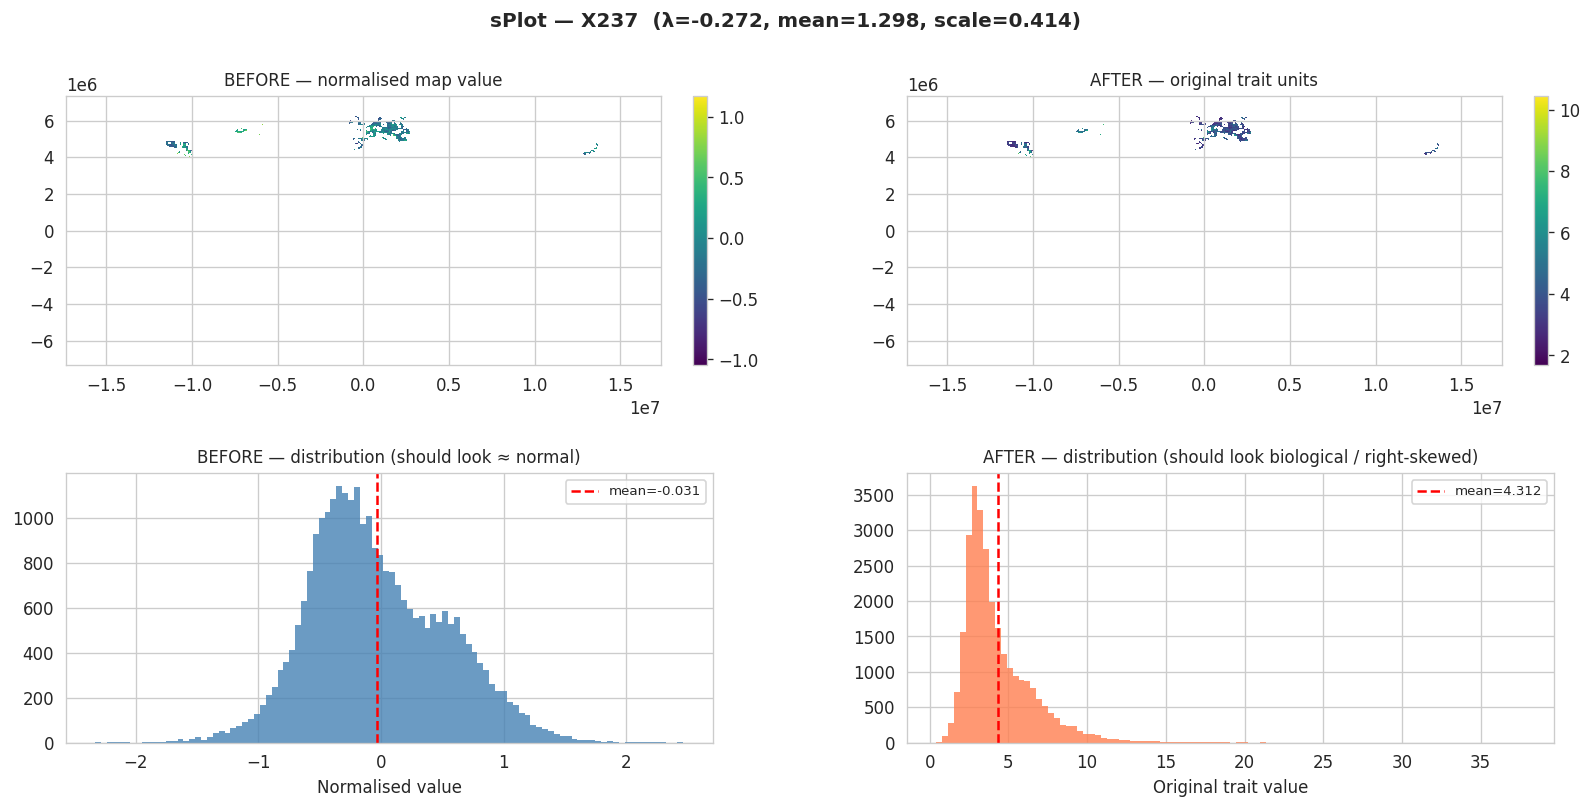

  BEFORE  → min=-2.3292, max=2.4648, mean=-0.0306, std=0.5574
  AFTER   → min=0.4181, max=37.7790, mean=4.3121, std=2.2580


In [16]:
# ── Same for the matching sPlot trait ───────────────────────────────────────
# Find the sPlot file with the same trait ID
matching_splot = [f for f, t in splot_map.items() if t == example_trait]

if matching_splot:
    print(f"File:  {os.path.basename(matching_splot[0])}")
    print(f"Trait: {example_trait}")
    print()
    plot_before_after(matching_splot[0], example_trait, source_label="sPlot")
else:
    print(f"⚠️  No sPlot file found for trait {example_trait}")

---
## 5. Validation: GBIF vs sPlot in Original Space

After back-transforming, GBIF and sPlot distributions for the same trait should be **broadly similar** (same biological quantity), though they may differ in coverage and density.

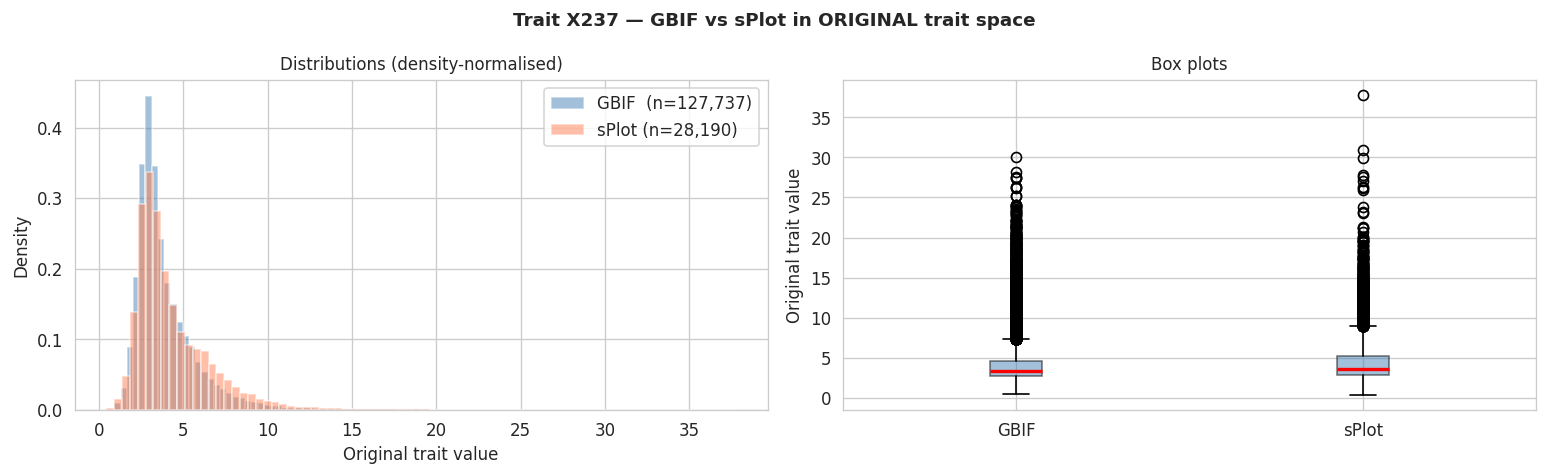

        n_valid     min      p5  median    mean     p95        max     std
source                                                                    
GBIF     127737  0.5288  2.0241  3.3596  3.9300  7.5283  30.074100  1.9038
sPlot     28190  0.4181  2.0095  3.6085  4.3121  8.6476  37.778999  2.2580


In [ ]:
def compare_gbif_splot_original(trait_id, gbif_file, splot_file):
    """
    Overlay GBIF and sPlot distributions in original trait space.
    """
    gbif_orig, _ = back_transform_tif(gbif_file, trait_id)
    splot_orig, _ = back_transform_tif(splot_file, trait_id)

    gbif_valid = gbif_orig[~np.isnan(gbif_orig)]
    splot_valid = splot_orig[~np.isnan(splot_orig)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        f"Trait {trait_id} — GBIF vs sPlot in ORIGINAL trait space",
        fontsize=11,
        fontweight="bold",
    )

    # Overlaid histograms
    axes[0].hist(
        gbif_valid,
        bins=80,
        density=True,
        alpha=0.5,
        color="steelblue",
        label=f"GBIF  (n={gbif_valid.size:,})",
    )
    axes[0].hist(
        splot_valid,
        bins=80,
        density=True,
        alpha=0.5,
        color="coral",
        label=f"sPlot (n={splot_valid.size:,})",
    )
    axes[0].set_xlabel("Original trait value")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Distributions (density-normalised)")
    axes[0].legend()

    # Box plots
    axes[1].boxplot(
        [gbif_valid, splot_valid],
        labels=["GBIF", "sPlot"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
        medianprops=dict(color="red", lw=2),
    )
    axes[1].set_ylabel("Original trait value")
    axes[1].set_title("Box plots")

    plt.tight_layout()
    plt.show()

    stats = pd.DataFrame(
        {
            "source": ["GBIF", "sPlot"],
            "n_valid": [gbif_valid.size, splot_valid.size],
            "min": [gbif_valid.min(), splot_valid.min()],
            "p5": [np.percentile(gbif_valid, 5), np.percentile(splot_valid, 5)],
            "median": [np.median(gbif_valid), np.median(splot_valid)],
            "mean": [gbif_valid.mean(), splot_valid.mean()],
            "p95": [np.percentile(gbif_valid, 95), np.percentile(splot_valid, 95)],
            "max": [gbif_valid.max(), splot_valid.max()],
            "std": [gbif_valid.std(), splot_valid.std()],
        }
    ).set_index("source")
    print(stats.round(4))


# Run for the example trait
if matching_splot:
    compare_gbif_splot_original(example_trait, example_gbif_file, matching_splot[0])

---
## 6. Bulk Back-Transform: All 31 Traits

Once we're satisfied the back-transform is correct, run it on all traits for both GBIF and sPlot and save the results as new TIF files.

In [19]:
def save_back_transformed_tif(filepath, trait_id, out_folder, source_label):
    """
    Back-transform one TIF and save to out_folder.
    Output filename keeps the original name with '_original' suffix.
    """
    out_data, profile = back_transform_tif(filepath, trait_id)

    fname = os.path.basename(filepath).replace(".tif", "_original.tif")
    out_path = os.path.join(out_folder, fname)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(out_data, 1)

    valid = out_data[~np.isnan(out_data)]
    return {
        "source": source_label,
        "trait": trait_id,
        "file_in": os.path.basename(filepath),
        "file_out": fname,
        "n_valid": valid.size,
        "min": float(valid.min()) if valid.size else np.nan,
        "max": float(valid.max()) if valid.size else np.nan,
        "mean": float(valid.mean()) if valid.size else np.nan,
        "median": float(np.median(valid)) if valid.size else np.nan,
        "std": float(valid.std()) if valid.size else np.nan,
    }


print("✅ Save function defined")

✅ Save function defined


In [20]:
# ── Process all GBIF traits ──────────────────────────────────────────────────
print("Processing GBIF...")
gbif_results = []
for fpath, trait_id in gbif_map.items():
    if trait_id is None:
        print(f"  ⚠️  Skipping {os.path.basename(fpath)} — no trait match")
        continue
    result = save_back_transformed_tif(fpath, trait_id, PATHS["out_gbif"], "GBIF")
    gbif_results.append(result)
    print(
        f"  ✅  {result['trait']:10s}  mean={result['mean']:8.3f}  "
        f"min={result['min']:8.3f}  max={result['max']:8.3f}"
    )

print(f"\nDone! {len(gbif_results)}/31 GBIF traits saved to: {PATHS['out_gbif']}")

Processing GBIF...
  ✅  X1080       mean=2748.467  min=  39.205  max=59221.410
  ✅  X13         mean= 451.651  min= 356.837  max= 543.279
  ✅  X138        mean= 606.579  min=   1.420  max=2845746.000
  ✅  X14         mean=  22.444  min=   7.587  max=  52.981
  ✅  X144        mean=  58.799  min=   4.311  max=1063.853
  ✅  X145        mean=   1.833  min=   0.054  max=  43.118
  ✅  X146        mean=  22.000  min=   7.567  max=  64.144
  ✅  X15         mean=   1.643  min=   0.421  max=   7.311
  ✅  X163        mean=   0.349  min=  -0.001  max=  11.459
  ✅  X169        mean=  63.171  min=   2.873  max=3345.599
  ✅  X21         mean=   0.042  min=  -0.000  max=   0.948
  ⚠️  Skipping X223.tif — no trait match
  ⚠️  Skipping X224.tif — no trait match
  ✅  X237        mean=   3.930  min=   0.529  max=  30.074
  ✅  X26         mean=   8.714  min=   0.022  max=13811.083
  ✅  X27         mean=   4.025  min=   0.482  max=  60.478
  ✅  X281        mean=  61.901  min=   8.381  max= 297.279
  ✅  X282

In [21]:
# ── Process all sPlot traits ─────────────────────────────────────────────────
print("Processing sPlot...")
splot_results = []
for fpath, trait_id in splot_map.items():
    if trait_id is None:
        print(f"  ⚠️  Skipping {os.path.basename(fpath)} — no trait match")
        continue
    result = save_back_transformed_tif(fpath, trait_id, PATHS["out_splot"], "sPlot")
    splot_results.append(result)
    print(
        f"  ✅  {result['trait']:10s}  mean={result['mean']:8.3f}  "
        f"min={result['min']:8.3f}  max={result['max']:8.3f}"
    )

print(f"\nDone! {len(splot_results)}/31 sPlot traits saved to: {PATHS['out_splot']}")

Processing sPlot...
  ✅  X1080       mean=2791.443  min=  68.443  max=145793.094
  ✅  X13         mean= 460.797  min= 355.693  max= 545.466
  ✅  X138        mean=4007.565  min=   1.295  max=2845746.000
  ✅  X14         mean=  19.918  min=   6.061  max=  54.110
  ✅  X144        mean=  51.116  min=   1.321  max= 948.948
  ✅  X145        mean=   1.365  min=   0.036  max=  17.565
  ✅  X146        mean=  25.498  min=   7.975  max=  75.952
  ✅  X15         mean=   1.592  min=   0.262  max=   4.908
  ✅  X163        mean=   0.236  min=  -0.001  max=  19.535
  ✅  X169        mean= 198.695  min=   2.226  max=5072.189
  ✅  X21         mean=   0.049  min=  -0.000  max=   1.329
  ⚠️  Skipping X223.tif — no trait match
  ⚠️  Skipping X224.tif — no trait match
  ✅  X237        mean=   4.312  min=   0.418  max=  37.779
  ✅  X26         mean=   6.736  min=   0.007  max=7783.603
  ✅  X27         mean=   3.808  min=   0.384  max=  33.369
  ✅  X281        mean=  48.843  min=   6.556  max= 223.812
  ✅  X28

---
## 7. Summary Table & Validation Plots

In [28]:
# pd.set_option('display.max_rows', None)

# ── Combined summary table ───────────────────────────────────────────────────
all_results = pd.DataFrame(gbif_results + splot_results)
all_results = all_results.sort_values(["trait", "source"]).reset_index(drop=True)

print("Back-transformation summary:")
all_results[
    ["source", "trait", "n_valid", "min", "median", "mean", "max", "std"]
].round(4)

Back-transformation summary:


,source,trait,n_valid,min,median,mean,max,std
0,GBIF,X1080,127236,39.2052,2618.9795,2748.4668,5.922141e+04,1401.1638
1,sPlot,X1080,27413,68.4426,2404.4260,2791.4429,1.457931e+05,2326.0972
2,GBIF,X13,127038,356.8374,450.7681,451.6512,5.432786e+02,13.4149
3,sPlot,X13,27260,355.6932,458.8618,460.7974,5.454658e+02,22.2641
4,GBIF,X138,127411,1.4205,292.0819,606.5787,2.845746e+06,13153.2910
5,sPlot,X138,27118,1.2949,392.4709,4007.5654,2.845746e+06,24720.2969
6,GBIF,X14,127100,7.5869,22.4468,22.4445,5.298100e+01,3.3927
7,sPlot,X14,28206,6.0606,20.1927,19.9183,5.411020e+01,4.2854
8,GBIF,X144,127791,4.3110,52.9790,58.7987,1.063853e+03,33.6703
9,sPlot,X144,27518,1.3214,47.1234,51.1155,9.489479e+02,27.2830


In [ ]:
# Flag traits where mean or max looks unrealistic
print("Checking for potential issues...")
issues = all_results[
    all_results["max"].isna()
    | (all_results["max"] > 1e6)
    | (all_results["min"] < -1e3)
    | (all_results["n_valid"] == 0)
]
if len(issues) > 0:
    print("⚠️  Potential issues found:")
    print(issues[["source", "trait", "min", "max", "n_valid"]])
else:
    print("✅  No obvious issues found")

Checking for potential issues...
⚠️  Potential issues found:
  source trait       min        max  n_valid
4   GBIF  X138  1.420454  2845746.0   127411
5  sPlot  X138  1.294866  2845746.0    27118


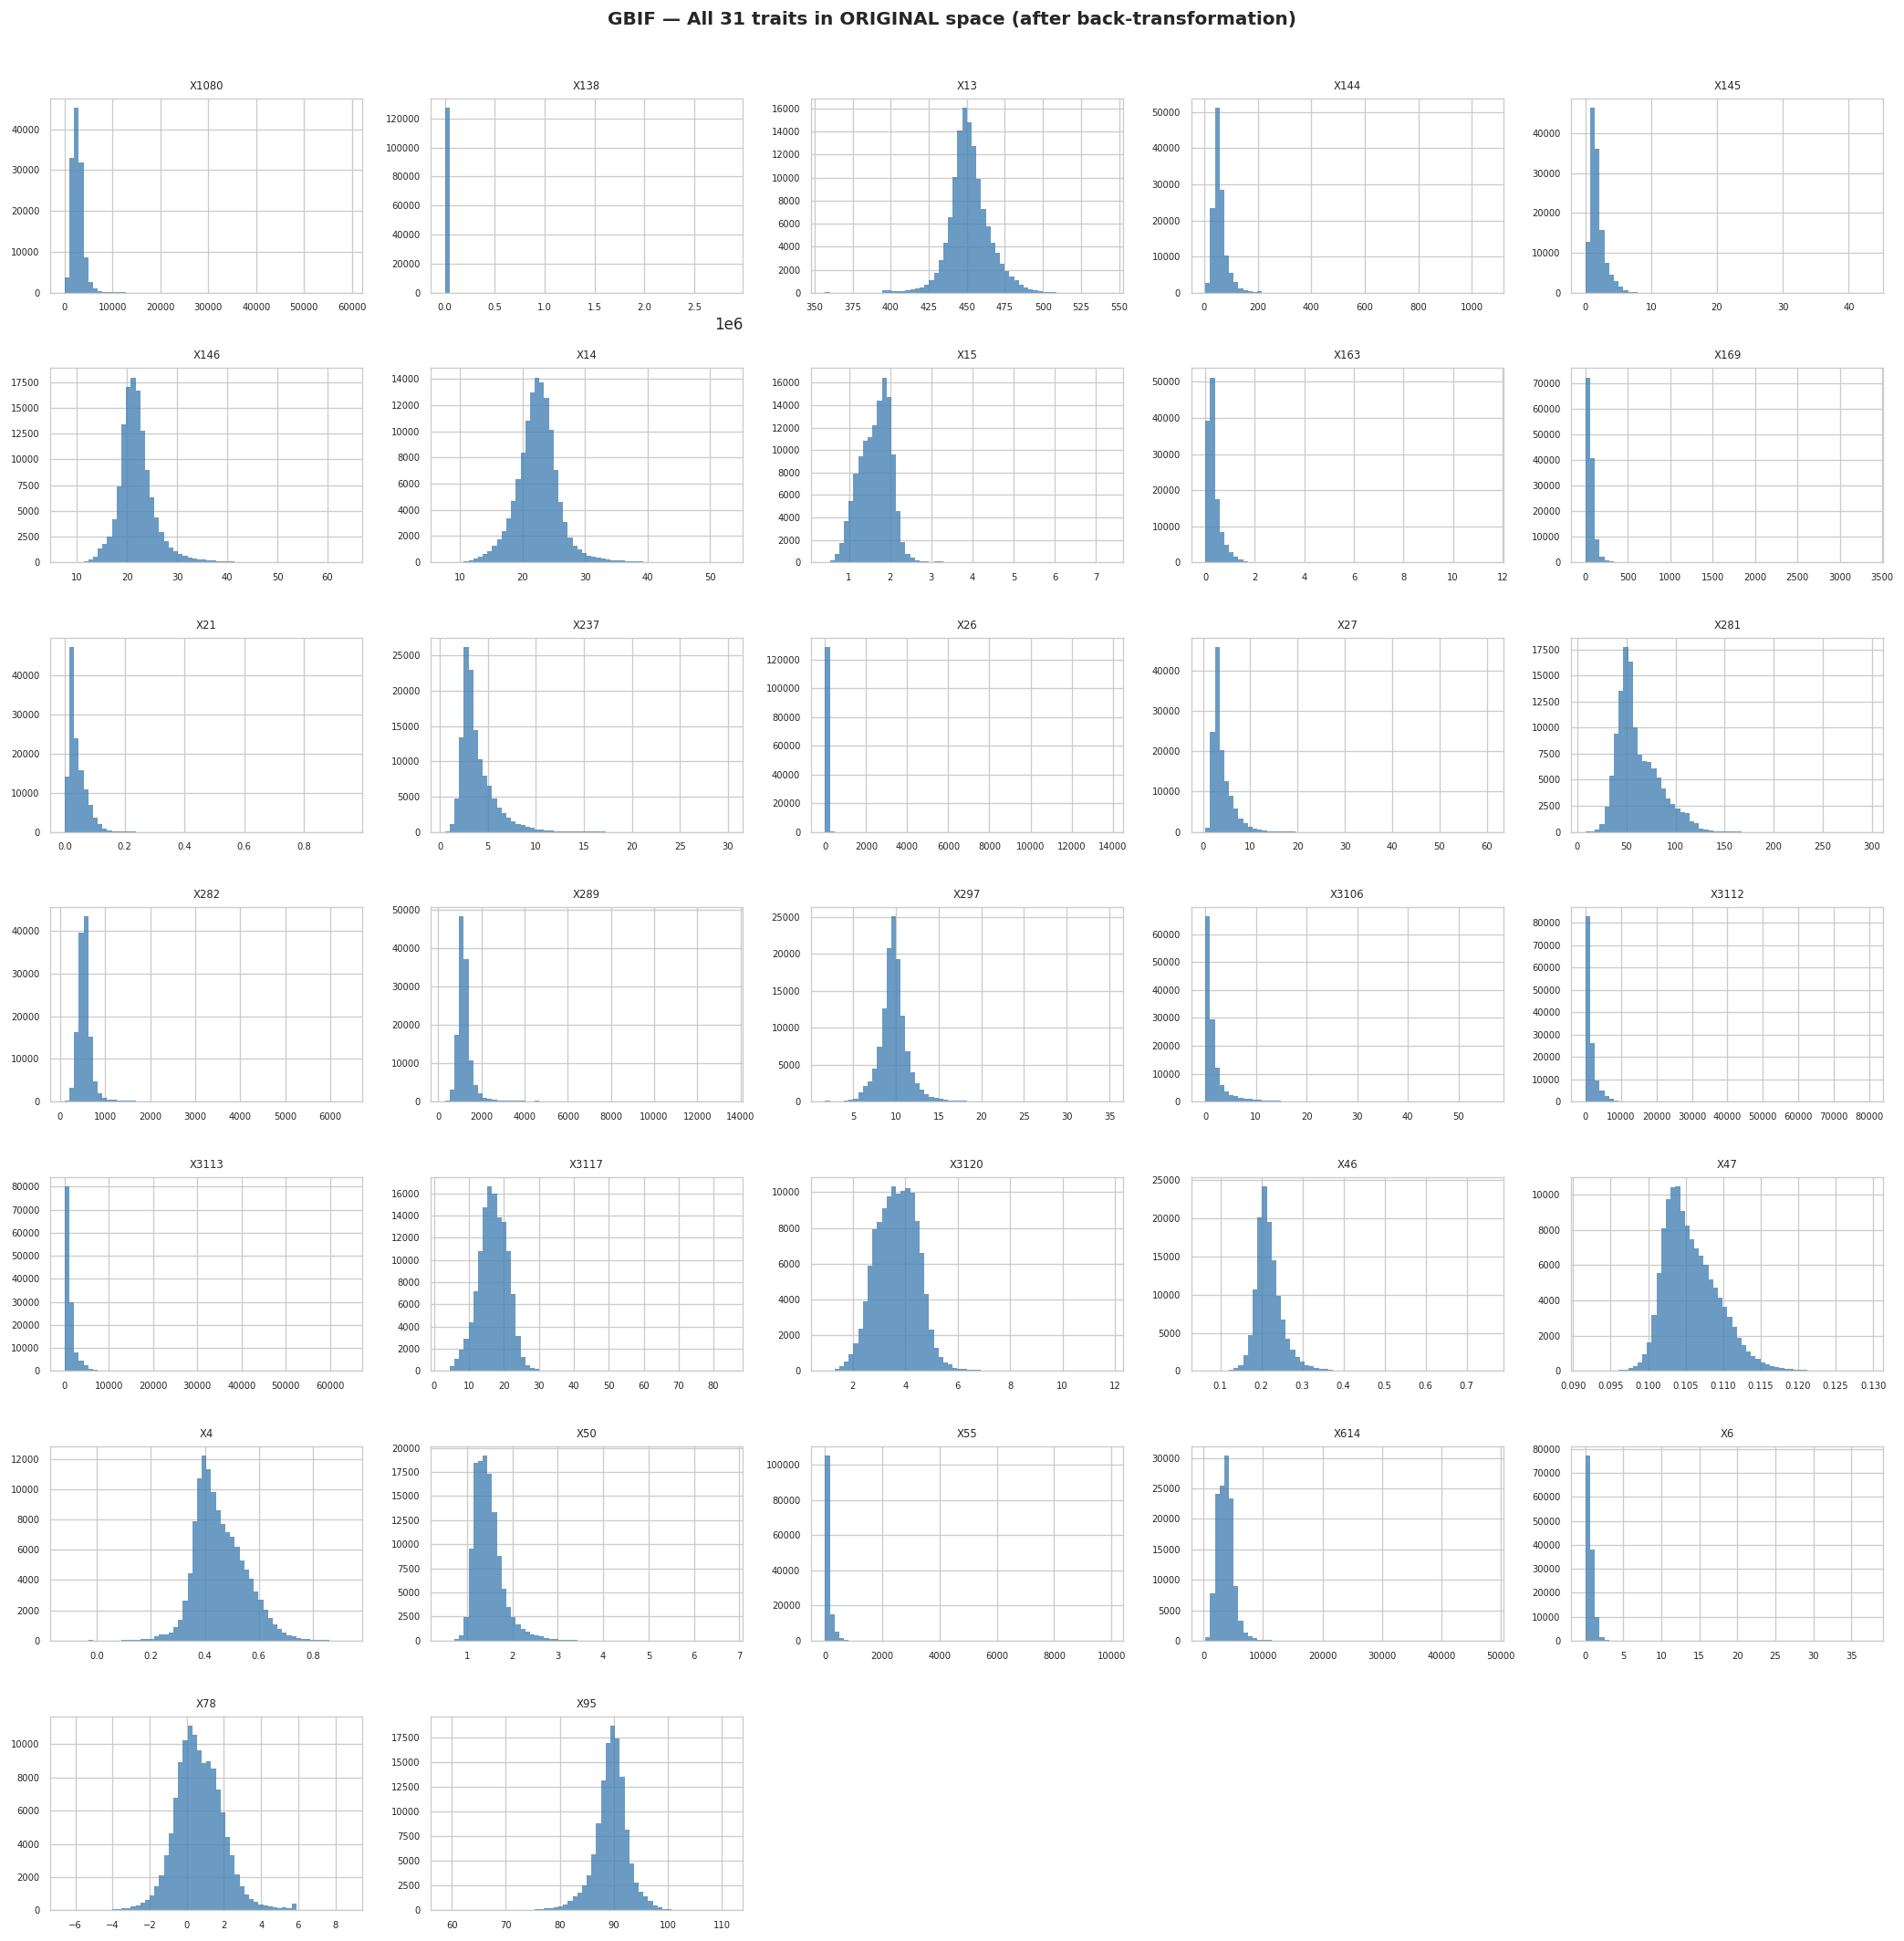

In [24]:
# ── Grid plot: all 31 traits — GBIF original distributions ──────────────────
out_gbif_files = sorted(glob.glob(os.path.join(PATHS["out_gbif"], "*.tif")))

n = len(out_gbif_files)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()

for i, fpath in enumerate(out_gbif_files):
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(np.float32)
    valid = data[~np.isnan(data)]
    axes[i].hist(valid, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    trait_label = os.path.basename(fpath).replace("_original.tif", "")
    axes[i].set_title(trait_label, fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "GBIF — All 31 traits in ORIGINAL space (after back-transformation)",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

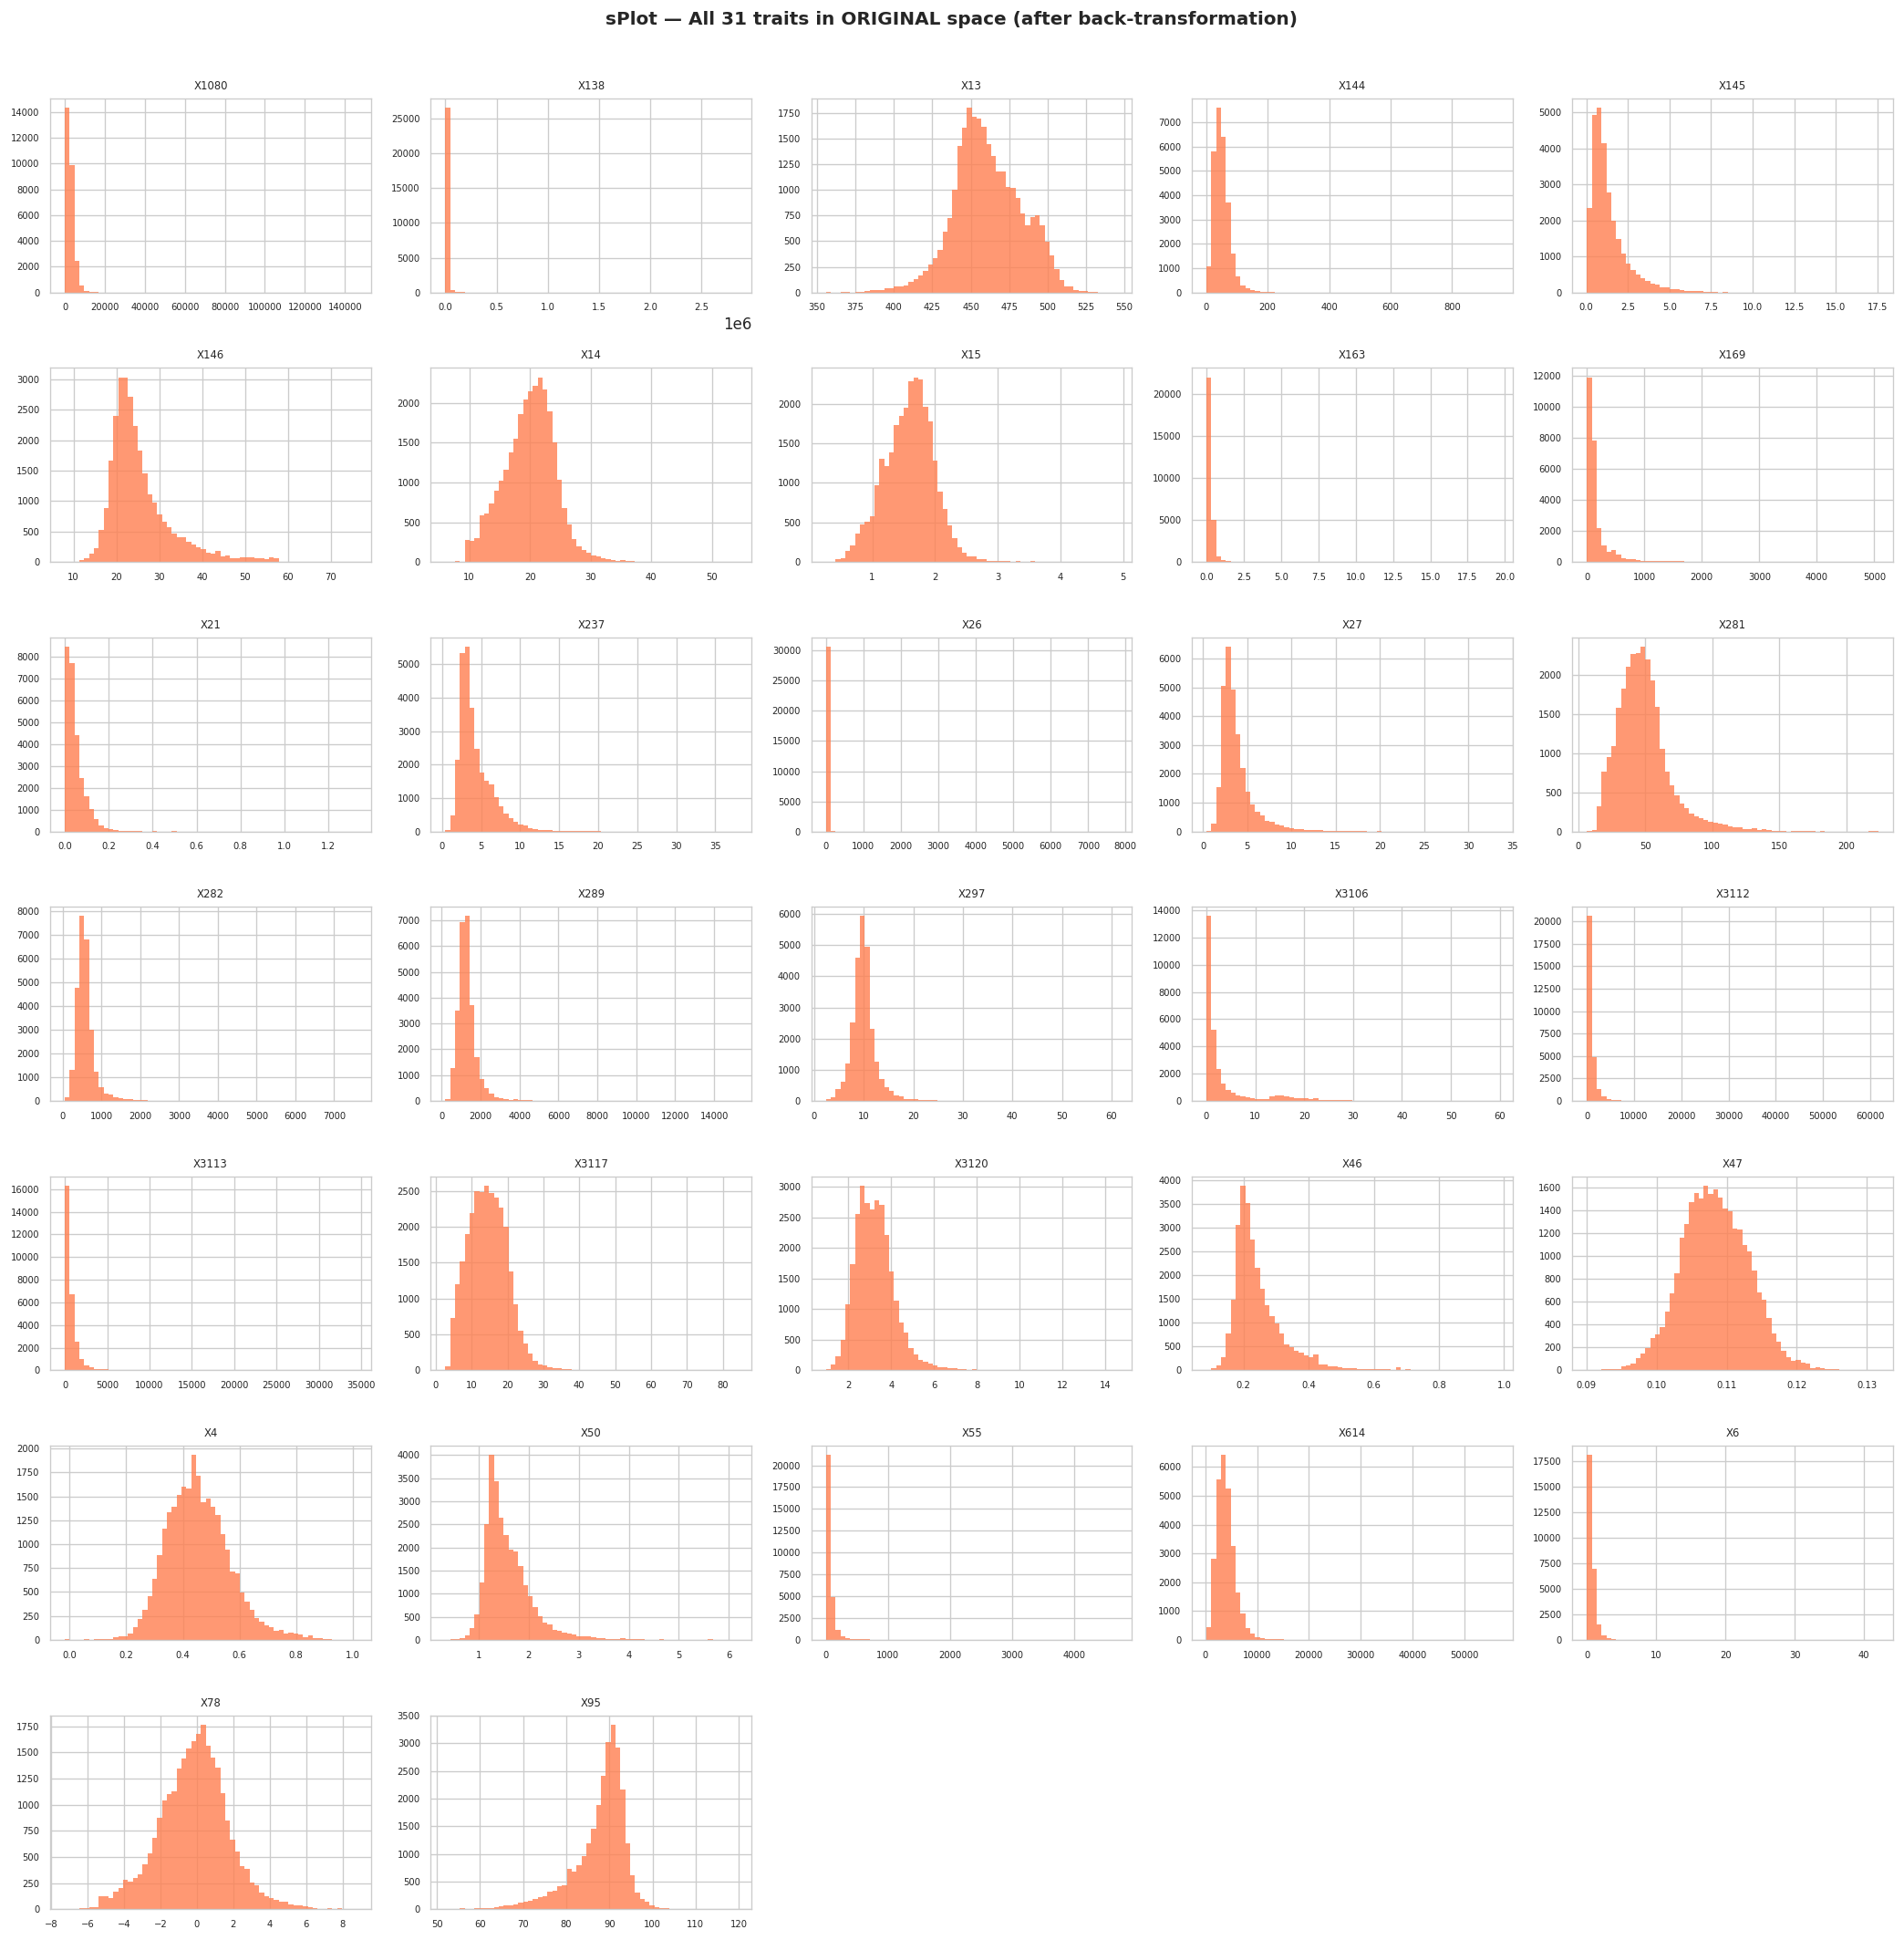

In [25]:
# ── Grid plot: all 31 traits — sPlot original distributions ─────────────────
out_splot_files = sorted(glob.glob(os.path.join(PATHS["out_splot"], "*.tif")))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()

for i, fpath in enumerate(out_splot_files):
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(np.float32)
    valid = data[~np.isnan(data)]
    axes[i].hist(valid, bins=60, color="coral", edgecolor="none", alpha=0.8)
    trait_label = os.path.basename(fpath).replace("_original.tif", "")
    axes[i].set_title(trait_label, fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "sPlot — All 31 traits in ORIGINAL space (after back-transformation)",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()